На основе подготовленной для нейросети таблицы данных с HeadHunter создайте 6 архитектур нейросетей, поэкспериментируйте с гиперпараметрами.
Используйте только числовые данные, текстовые не подавайте.

Результаты в конце проанализируйте.

Перед началом выполнения, пожалуйста, запустите раздел "Подготовка".

## Подготовка

In [1]:
# Импорт библиотек

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

import gdown
import re

%matplotlib inline

In [2]:
# Загрузка и подготовка данных

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l10/hh_fixed.csv', None, quiet=True)

df = pd.read_csv('hh_fixed.csv', index_col=0)
print(f"Размер данных: {df.shape}")
df.head(3)

Размер данных: (62967, 12)


,"Пол, возраст",ЗП,Ищет работу на должность:,Город,Занятость,График,Опыт (двойное нажатие для полной версии),Последенее/нынешнее место работы,Последеняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 29 лет , родился 16 мая 1989",40000 руб.,Специалист по поддержке чата(support team) дом...,"Новороссийск , готов к переезду (Анапа, Геленд...",полная занятость,полный день,Опыт работы 3 года 9 месяцев Специалист по по...,"ООО ""Гольфстрим""",Генеральный директор,Высшее образование 2011 Международный юридиче...,26.04.2019 08:04,Не указано
1,"Мужчина , 38 лет , родился 25 мая 1980",40000 руб.,Системный администратор,"Новосибирск , м. Березовая роща , не готов к ...",полная занятость,полный день,Опыт работы 11 лет 11 месяцев Системный админ...,ООО «Завод модульных технологий»,Системный администратор,Высшее образование 2002 Новосибирский государс...,26.04.2019 04:30,Не указано
2,"Мужчина , 35 лет , родился 14 июня 1983",300000 руб.,DevOps TeamLead / DevOps архитектор,"Москва , готов к переезду , готов к редким ком...",полная занятость,полный день,Опыт работы 12 лет 11 месяцев DevOps TeamLead...,Банк ВТБ (ПАО),Начальник отдела методологии разработки (DevOp...,DevOps TeamLead / DevOps архитектор 300 000 ру...,09.04.2019 14:40,Не указано


In [3]:
# Настройка номеров столбцов

COL_SEX_AGE = df.columns.get_loc('Пол, возраст')
COL_SALARY = df.columns.get_loc('ЗП')
COL_POS_SEEK = df.columns.get_loc('Ищет работу на должность:')
COL_POS_PREV = df.columns.get_loc('Последеняя/нынешняя должность')
COL_CITY = df.columns.get_loc('Город')
COL_EMPL = df.columns.get_loc('Занятость')
COL_SCHED = df.columns.get_loc('График')
COL_EXP = df.columns.get_loc('Опыт (двойное нажатие для полной версии)')
COL_EDU = df.columns.get_loc('Образование и ВУЗ')
COL_UPDATED = df.columns.get_loc('Обновление резюме')

In [4]:
def purify(x):
    if isinstance(x, str):
        x = x.replace('\n', ' ').replace('\xa0', '').strip().lower()
    return x

def extract_year(x):
    try:
        return int(re.search(r'\d\d.\d\d.(\d{4})', x)[1])
    except (IndexError, TypeError, ValueError):
        return 0

In [5]:
# Параметрические данные (курсы, классы)

currency_rate = {
    'usd': 65., 'kzt': 0.17, 'грн': 2.6, 'белруб': 30.5,
    'eur': 70., 'kgs': 0.9, 'сум': 0.007, 'azn': 37.5
}

age_class = [0, [18, 23, 28, 33, 38, 43, 48, 53, 58, 63]]
experience_class = [0, [7, 13, 25, 37, 61, 97, 121, 157, 193, 241]]

city_class = [0, {
    'москва': 0, 'санкт-петербург': 1, 'новосибирск': 2,
    'екатеринбург': 2, 'нижний новгород': 2, 'казань': 2,
    'челябинск': 2, 'омск': 2, 'самара': 2, 'ростов-на-дону': 2,
    'уфа': 2, 'красноярск': 2, 'пермь': 2, 'воронеж': 2,
    'волгоград': 2, 'прочие города': 3
}]

employment_class = [0, {
    'стажировка': 0, 'частичная занятость': 1,
    'проектная работа': 2, 'полная занятость': 3
}]

schedule_class = [0, {
    'гибкий график': 0, 'полный день': 1,
    'сменный график': 2, 'удаленная работа': 3
}]

education_class = [0, {
    'высшее образование': 0, 'higher education': 0,
    'среднее специальное': 1, 'неоконченное высшее': 2,
    'среднее образование': 3
}]

# Вычисление счетчиков
for class_desc in [age_class, experience_class, city_class,
                   employment_class, schedule_class, education_class]:
    if isinstance(class_desc[1], list):
        class_desc[0] = len(class_desc[1]) + 1
    else:
        class_desc[0] = max(class_desc[1].values()) + 1

In [6]:
# One-hot и multi-вектор функции

def int_to_ohe(arg, class_list):
    num_classes = class_list[0]
    for i in range(num_classes - 1):
        if arg < class_list[1][i]:
            cls = i
            break
    else:
        cls = num_classes - 1
    one_hot = np.zeros(num_classes)
    one_hot[cls] = 1.0
    return one_hot

def str_to_multi(arg, class_dict):
    num_classes = class_dict[0]
    result = np.zeros(num_classes)
    for value, cls in class_dict[1].items():
        if value in arg:
            result[cls] = 1.0
    return result

In [7]:
# Функции разбора данных

base_update_year = 2019

def extract_sex_age_years(arg):
    sex = 1. if 'муж' in arg else 0.
    try:
        years = base_update_year - int(re.search(r'\d{4}', arg)[0])
    except (IndexError, TypeError, ValueError):
        years = 0
    return sex, years

def age_years_to_ohe(arg):
    return int_to_ohe(arg, age_class)

def experience_months_to_ohe(arg):
    return int_to_ohe(arg, experience_class)

def extract_salary(arg):
    try:
        value = float(re.search(r'\d+', arg)[0])
        for currency, rate in currency_rate.items():
            if currency in arg:
                value *= rate
                break
    except TypeError:
        value = 0.
    return value / 1000.

def extract_city_to_ohe(arg):
    num_classes = city_class[0]
    split_array = re.split(r'[ ,.:()?!]', arg)
    for word in split_array:
        city_cls = city_class[1].get(word, -1)
        if city_cls >= 0:
            break
    else:
        city_cls = num_classes - 1
    one_hot = np.zeros(num_classes)
    one_hot[city_cls] = 1.0
    return one_hot

def extract_employment_to_multi(arg):
    return str_to_multi(arg, employment_class)

def extract_schedule_to_multi(arg):
    return str_to_multi(arg, schedule_class)

def extract_education_to_multi(arg):
    result = str_to_multi(arg, education_class)
    if result[2] > 0.:
        result[0] = 0.
    return result

def extract_experience_months(arg):
    try:
        years = int(re.search(r'(\d+)\s+(год.?|лет)', arg)[1])
    except (IndexError, TypeError, ValueError):
        years = 0
    try:
        months = int(re.search(r'(\d+)\s+месяц', arg)[1])
    except (IndexError, TypeError, ValueError):
        months = 0
    return years * 12 + months

In [8]:
# Формирование выборки

def extract_row_data(row):
    sex, age = extract_sex_age_years(row[COL_SEX_AGE])
    sex_vec = np.array([sex])
    age_ohe = age_years_to_ohe(age)
    city_ohe = extract_city_to_ohe(row[COL_CITY])
    empl_multi = extract_employment_to_multi(row[COL_EMPL])
    sсhed_multi = extract_schedule_to_multi(row[COL_SCHED])
    edu_multi = extract_education_to_multi(row[COL_EDU])
    exp_months = extract_experience_months(row[COL_EXP])
    exp_ohe = experience_months_to_ohe(exp_months)
    salary = extract_salary(row[COL_SALARY])
    salary_vec = np.array([salary])

    x_data = np.hstack([sex_vec, age_ohe, city_ohe, empl_multi,
                        sсhed_multi, edu_multi, exp_ohe])
    return x_data, salary_vec

def construct_train_data(row_list):
    x_data = []
    y_data = []
    for row in row_list:
        x, y = extract_row_data(row)
        if y[0] > 0:
            x_data.append(x)
            y_data.append(y)
    return np.array(x_data), np.array(y_data)

x_train_01, y_train = construct_train_data(df.values)
print(x_train_01.shape, y_train.shape)

(62967, 39) (62967, 1)


In [9]:
# Функция отрисовки графика истории обучения

def plot_history(history_dict):
    plt.plot(history_dict['train_mae'], label='Train MAE', linewidth=1.5)
    plt.plot(history_dict['val_mae'], label='Val MAE', linewidth=1.5)
    plt.xlabel('Эпоха')
    plt.ylabel('MAE (нормированная)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [10]:
# Подготовка данных

from sklearn.model_selection import train_test_split

# Масштабирование
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(x_train_01)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y_train)

# Разбиение
X_train, X_val, y_train_scaled, y_val_scaled = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# Преобразование в тензоры
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32).reshape(-1, 1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val_scaled, dtype=torch.float32).reshape(-1, 1)

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print(f"Обучающая выборка: {X_train.shape[0]} samples")
print(f"Валидационная выборка: {X_val.shape[0]} samples")

Обучающая выборка: 50373 samples
Валидационная выборка: 12594 samples


In [14]:
# Функция обучения модели

def train_model(model, train_loader, val_loader, epochs=50, lr=0.001, patience=10):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
    best_val_mae = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_mae = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_mae += torch.abs(y_pred - y_batch).sum().item()

        train_loss /= len(train_loader.dataset)
        train_mae /= len(train_loader.dataset)

        # Validation
        model.eval()
        val_loss = 0.0
        val_mae = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                val_mae += torch.abs(y_pred - y_batch).sum().item()

        val_loss /= len(val_loader.dataset)
        val_mae /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_mae'].append(train_mae)
        history['val_mae'].append(val_mae)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs}: train_loss={train_loss:.4f}, train_mae={train_mae:.4f}, val_loss={val_loss:.4f}, val_mae={val_mae:.4f}, lr={current_lr:.6f}")

        scheduler.step(val_loss)

        # Early stopping
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_state)
    return model, history

In [23]:
# Архитектура №1 — базовая (1 скрытый слой)

class Model1_Basic(nn.Module):
    def __init__(self, input_dim):
        super(Model1_Basic, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model1 = Model1_Basic(input_dim)
print(model1)
model1, history1 = train_model(model1, train_loader, val_loader, epochs=50)

Model1_Basic(
  (net): Sequential(
    (0): Linear(in_features=39, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)
Epoch 1/50: train_loss=0.9110, train_mae=0.5925, val_loss=0.8337, val_mae=0.5849, lr=0.001000
Epoch 2/50: train_loss=0.8850, train_mae=0.5806, val_loss=0.8288, val_mae=0.5797, lr=0.001000
Epoch 3/50: train_loss=0.8823, train_mae=0.5783, val_loss=0.8275, val_mae=0.5842, lr=0.001000
Epoch 4/50: train_loss=0.8804, train_mae=0.5773, val_loss=0.8282, val_mae=0.5806, lr=0.001000
Epoch 5/50: train_loss=0.8787, train_mae=0.5761, val_loss=0.8263, val_mae=0.5724, lr=0.001000
Epoch 6/50: train_loss=0.8783, train_mae=0.5755, val_loss=0.8255, val_mae=0.5758, lr=0.001000
Epoch 7/50: train_loss=0.8774, train_mae=0.5754, val_loss=0.8278, val_mae=0.5896, lr=0.001000
Epoch 8/50: train_loss=0.8770, train_mae=0.5755, val_loss=0.8261, val_mae=0.5814, lr=0.001000
Epoch 9/50: train_loss=0.8764, train_mae=0.5748, val_loss=0.8261, val_ma

In [16]:
# Архитектура №2 — глубокая сеть

class DeepSalaryModel(nn.Module):
    def __init__(self, input_dim):
        super(DeepSalaryModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model2 = DeepSalaryModel(input_dim)
print(model2)
model2, history2 = train_model(model2, train_loader, val_loader, epochs=50)

DeepSalaryModel(
  (net): Sequential(
    (0): Linear(in_features=39, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)
Epoch 1/50: train_loss=0.9011, train_mae=0.5876, val_loss=0.8319, val_mae=0.5673, lr=0.001000
Epoch 2/50: train_loss=0.8841, train_mae=0.5790, val_loss=0.8295, val_mae=0.5715, lr=0.001000
Epoch 3/50: train_loss=0.8827, train_mae=0.5767, val_loss=0.8264, val_mae=0.5750, lr=0.001000
Epoch 4/50: train_loss=0.8792, train_mae=0.5766, val_loss=0.8262, val_mae=0.5706, lr=0.001000
Epoch 5/50: train_loss=0.8769, train_mae=0.5749, val_loss=0.8251, val_mae=0.5808, lr=0.001000
Epoch 6/50: train_loss=0.8760, train_mae=0.5739, val_loss=0.8254, val_mae=0.5835, lr=0.001000
Epoch 7/50: train_loss=

In [17]:
# Архитектура №3 — с Dropout

class DropoutSalaryModel(nn.Module):
    def __init__(self, input_dim):
        super(DropoutSalaryModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

model3 = DropoutSalaryModel(input_dim)
print(model3)
model3, history3 = train_model(model3, train_loader, val_loader, epochs=50)

DropoutSalaryModel(
  (net): Sequential(
    (0): Linear(in_features=39, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=1, bias=True)
  )
)
Epoch 1/50: train_loss=0.9141, train_mae=0.5952, val_loss=0.8362, val_mae=0.5973, lr=0.001000
Epoch 2/50: train_loss=0.8954, train_mae=0.5853, val_loss=0.8291, val_mae=0.5853, lr=0.001000
Epoch 3/50: train_loss=0.8898, train_mae=0.5827, val_loss=0.8294, val_mae=0.5861, lr=0.001000
Epoch 4/50: train_loss=0.8882, train_mae=0.5815, val_loss=0.8292, val_mae=0.5783, lr=0.001000
Epoch 5/50: train_loss=0.8862, train_mae=0.5801, val_loss=0.8271, val_mae=0.5831, lr=0.001000
Epoch 6/50: train_loss=0.8835, train_mae=0.5796, val_loss=0.8275, val_mae

In [18]:
# Архитектура №4 — с BatchNormalization

class BatchNormSalaryModel(nn.Module):
    def __init__(self, input_dim):
        super(BatchNormSalaryModel, self).__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

model4 = BatchNormSalaryModel(input_dim)
print(model4)
model4, history4 = train_model(model4, train_loader, val_loader, epochs=50)

BatchNormSalaryModel(
  (net): Sequential(
    (0): BatchNorm1d(39, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Linear(in_features=39, out_features=128, bias=True)
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=1, bias=True)
  )
)
Epoch 1/50: train_loss=0.9135, train_mae=0.5961, val_loss=0.8343, val_mae=0.5862, lr=0.001000
Epoch 2/50: train_loss=0.8884, train_mae=0.5812, val_loss=0.8350, val_mae=0.5910, lr=0.001000
Epoch 3/50: train_loss=0.8822, train_mae=0.5785, val_loss=0.8288, val_mae=0.5774, lr=0.001000
Epoch 4/50: trai

In [19]:
# Архитектура №5 — узкая сеть (32→16→8)

class NarrowSalaryModel(nn.Module):
    def __init__(self, input_dim):
        super(NarrowSalaryModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)

model5 = NarrowSalaryModel(input_dim)
print(model5)
model5, history5 = train_model(model5, train_loader, val_loader, epochs=50)

NarrowSalaryModel(
  (net): Sequential(
    (0): Linear(in_features=39, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)
Epoch 1/50: train_loss=0.9371, train_mae=0.5933, val_loss=0.8326, val_mae=0.5807, lr=0.001000
Epoch 2/50: train_loss=0.8849, train_mae=0.5786, val_loss=0.8299, val_mae=0.5785, lr=0.001000
Epoch 3/50: train_loss=0.8819, train_mae=0.5765, val_loss=0.8270, val_mae=0.5771, lr=0.001000
Epoch 4/50: train_loss=0.8802, train_mae=0.5757, val_loss=0.8278, val_mae=0.5803, lr=0.001000
Epoch 5/50: train_loss=0.8787, train_mae=0.5756, val_loss=0.8293, val_mae=0.5861, lr=0.001000
Epoch 6/50: train_loss=0.8787, train_mae=0.5751, val_loss=0.8275, val_mae=0.5858, lr=0.001000
Epoch 7/50: train_loss=0.8784, train_mae=0.5754, val_loss=0.8264, val_mae=0.5722, lr=0.001000
Epoch 8/50:

In [22]:
# Архитектура №6 — LR Annealing

class LRSalaryModel(nn.Module):
    def __init__(self, input_dim):
        super(LRSalaryModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model6 = LRSalaryModel(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model6.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

def train_lr_model(model, train_loader, val_loader, epochs=50, patience=10):
    history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
    best_val_mae = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_mae = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_mae += torch.abs(y_pred - y_batch).sum().item()

        train_loss /= len(train_loader.dataset)
        train_mae /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_mae = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item() * X_batch.size(0)
                val_mae += torch.abs(y_pred - y_batch).sum().item()

        val_loss /= len(val_loader.dataset)
        val_mae /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_mae'].append(train_mae)
        history['val_mae'].append(val_mae)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{epochs}: train_loss={train_loss:.4f}, train_mae={train_mae:.4f}, val_loss={val_loss:.4f}, val_mae={val_mae:.4f}, lr={current_lr:.6f}")

        scheduler.step(val_loss)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_state)
    return model, history

model6, history6 = train_lr_model(model6, train_loader, val_loader, epochs=50)

Epoch 1/50: train_loss=0.9064, train_mae=0.5913, val_loss=0.8309, val_mae=0.5895, lr=0.001000
Epoch 2/50: train_loss=0.8844, train_mae=0.5796, val_loss=0.8313, val_mae=0.5793, lr=0.001000
Epoch 3/50: train_loss=0.8822, train_mae=0.5777, val_loss=0.8295, val_mae=0.5713, lr=0.001000
Epoch 4/50: train_loss=0.8782, train_mae=0.5764, val_loss=0.8252, val_mae=0.5725, lr=0.001000
Epoch 5/50: train_loss=0.8771, train_mae=0.5757, val_loss=0.8266, val_mae=0.5716, lr=0.001000
Epoch 6/50: train_loss=0.8758, train_mae=0.5760, val_loss=0.8238, val_mae=0.5817, lr=0.001000
Epoch 7/50: train_loss=0.8751, train_mae=0.5748, val_loss=0.8227, val_mae=0.5720, lr=0.001000
Epoch 8/50: train_loss=0.8730, train_mae=0.5741, val_loss=0.8246, val_mae=0.5822, lr=0.001000
Epoch 9/50: train_loss=0.8715, train_mae=0.5739, val_loss=0.8267, val_mae=0.5821, lr=0.001000
Epoch 10/50: train_loss=0.8712, train_mae=0.5738, val_loss=0.8236, val_mae=0.5682, lr=0.001000
Epoch 11/50: train_loss=0.8704, train_mae=0.5741, val_loss=

In [25]:
histories = [
    (history, "Базовая (128→64)"),
    (history2, "Глубокая (128→256→128→64)"),
    (history3, "Dropout"),
    (history4, "BatchNormalization"),
    (history5, "Узкая (32→16→8)"),
    (history6, "LR Annealing")
]

print("=" * 80)
print("СРАВНЕНИЕ АРХИТЕКТУР")
print("=" * 80)

for i, (hist, name) in enumerate(histories, 1):
    train_mae = hist['train_mae'][-1]
    val_mae = hist['val_mae'][-1]
    train_mae_real = train_mae * scaler_y.scale_[0]
    val_mae_real = val_mae * scaler_y.scale_[0]
    print(f"Модель {i} ({name:25}): Train MAE={train_mae_real:.2f} тыс. руб, Val MAE={val_mae_real:.2f} тыс. руб")

СРАВНЕНИЕ АРХИТЕКТУР
Модель 1 (Базовая (128→64)         ): Train MAE=41.61 тыс. руб, Val MAE=41.64 тыс. руб
Модель 2 (Глубокая (128→256→128→64)): Train MAE=41.43 тыс. руб, Val MAE=42.28 тыс. руб
Модель 3 (Dropout                  ): Train MAE=41.69 тыс. руб, Val MAE=42.87 тыс. руб
Модель 4 (BatchNormalization       ): Train MAE=41.01 тыс. руб, Val MAE=41.91 тыс. руб
Модель 5 (Узкая (32→16→8)          ): Train MAE=41.48 тыс. руб, Val MAE=41.58 тыс. руб
Модель 6 (LR Annealing             ): Train MAE=41.14 тыс. руб, Val MAE=41.48 тыс. руб


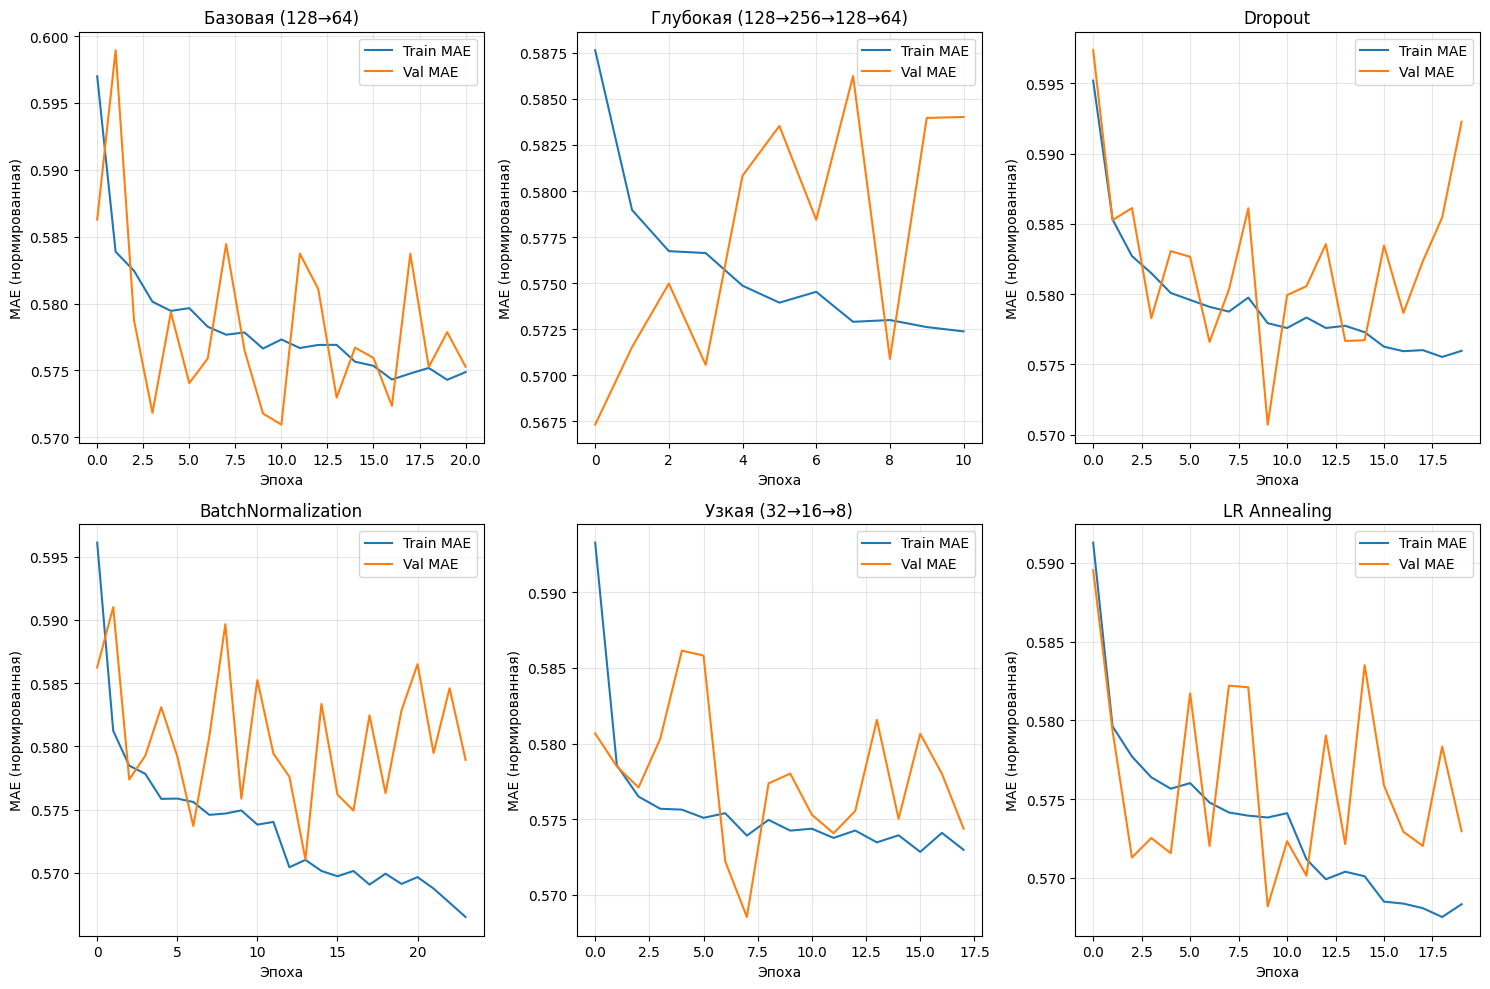

In [26]:
# Визуализация графиков всех моделей

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (hist, title) in enumerate(histories):
    axes[i].plot(hist['train_mae'], label='Train MAE', linewidth=1.5)
    axes[i].plot(hist['val_mae'], label='Val MAE', linewidth=1.5)
    axes[i].set_title(title)
    axes[i].set_xlabel('Эпоха')
    axes[i].set_ylabel('MAE (нормированная)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()